In [1]:
import numpy as np
from scipy.integrate import fixed_quad
import matplotlib.pyplot as plt

In [2]:
f = 1 
g = 1 # 10
cp = 1 # 1003.5
Pi0 = 1 # 0.864
gamma = 1.41
kappa = 1 # 65.00526358589575
Z = np.array([[1.94666077, 0.96859015], [0.0616024,  0.17076978]])
w = np.array([0, 0])
p1 = np.array([0.0, 0.40325799999999995]) 
p2 = np.array([1.36791, -0.0644098]) 
v1 = np.array([0.0, 0.40325768972316306])
v2 = np.array([1.367909985775398, -1.0])

In [3]:
def parametrize(t: float, p1: np.ndarray, p2: np.ndarray) -> np.ndarray:
    """
    Linear interpolation between p1 and p2.
    """
    return (1 - t) * p1 + t * p2

def edge_parametrize(
    t: float,
    p1: np.ndarray,
    p2: np.ndarray,
    zi: np.ndarray,
    zj: np.ndarray,
    f: float,
    g: float,
    wi: float,
    wj: float
) -> np.ndarray:
    """
    Non-linear edge parametrization.
    """
    pt = np.zeros(2)
    if zi[1] == zj[1]:
        # vertical-line case
        y = (1 - t) * p1[1] + t * p2[1]
        numerator = zj[1] * (wi - wj)
        denominator = f**2 * (zj[0] - zi[0])
        term1 = numerator / denominator
        term2 = 0.5 * (zi[0] + zj[0])
        pt[0] = term1 + term2
        pt[1] = y
    else:
        # parabolic-edge case
        x1 = (1 - t) * p1[0] + t * p2[0]
        numerator = (
            wi - wj
            + (f**2 / (2 * zj[1])) * (x1 - zj[0])**2
            - (f**2 / (2 * zi[1])) * (x1 - zi[0])**2
        )
        denominator = g * (1 / zi[1] - 1 / zj[1])
        pt[0] = x1
        pt[1] = numerator / denominator
    return pt

def cost_function(
    x1: float,
    x2: float,
    z1: float,
    z2: float,
    f: float,
    g: float,
    cp: float,
    Pi0: float
) -> float:
    """
    cost_function(x,y,z1,z2,f,g,cp,Pi0) = 1/z2 * [ (f^2/2)*(x1-z1)^2 + g*x2 ] − cp*Pi0
    """
    return (1.0 / z2) * ((f**2 / 2) * (x1 - z1)**2 + g * x2) - cp * Pi0

def chart_cost_function(x, z, f, g, cp, Pi0):
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)
    x1, x2 = x
    z1, z2 = z

    return (2*x2 - 2*x1*z1 + f**2 * z1**2 - 2*cp*Pi0*z2) / (2*z2)

def f_star_derivative(t: float, gamma: float, kappa: float) -> float:
    """
    f*'(t) for compressible case (Lebesgue limit is simply 1).
    """
    if t <= 0:
        return 0.0
    gamma_prime = gamma / (gamma - 1.0)
    return (kappa * gamma) ** (1.0 - gamma_prime) * t ** (gamma_prime - 1.0)

def norm_gradient_u(
    x: np.ndarray,
    zi: np.ndarray,
    zj: np.ndarray,
    f: float,
    g: float
) -> float:
    """
    ||∇u|| for given point x between support points zi, zj.
    """
    grad_x1 = (f**2 / zi[1]) * (x[0] - zi[0]) - (f**2 / zj[1]) * (x[0] - zj[0])
    grad_x2 = (g / zi[1]) - (g / zj[1])
    return np.hypot(grad_x1, grad_x2)

def Phi(p, f, g):
    """
    Compute Phi(p) = [p1/f^2, (p2 - p1^2/(2*f^2))/g].
    """
    p1, p2 = p
    first  = p1 / f**2
    second = (p2 - p1**2 / (2 * f**2)) / g
    return np.array([first, second])

def Phi_inverse(x, f, g):
    """
    Compute Phi^(-1)(x) = [f^2 * x1, g * x2 + f^2 * x1^2/2].
    """
    x1, x2 = x
    p1 = f**2 * x1
    p2 = g * x2 + 0.5 * f**2 * x1**2
    return np.array([p1, p2])


def phi_inverse_boundary(boundary_pts, f, g):
    """
    Map an array of boundary points under Phi^{-1}.

    Parameters
    ----------
    boundary_pts : (N,2) array_like
        Points (x1,x2) on the boundary in physical space.
    f, g : float
        Constants in the cost / change‐of‐variables.

    Returns
    -------
    (N,2) ndarray
        Points (p1,p2) = Phi^{-1}(x1,x2) in the new coordinate system,
        in the *same order* as the input.
    """
    pts = np.asarray(boundary_pts, dtype=float)
    x1 = pts[:, 0]
    x2 = pts[:, 1]

    p1 = f**2 * x1
    p2 = g * x2 + 0.5 * f**2 * x1**2

    return np.stack([p1, p2], axis=1)

## Validate the Hessian

In [4]:
def integrand_edge(
    t: float,
    p1: np.ndarray,
    p2: np.ndarray,
    X: np.ndarray,
    w: np.ndarray,
    f: float,
    g: float,
    cp: float,
    Pi0: float,
    gamma: float,
    kappa: float,
    i: int,
    j: int
) -> float:
    """
    Equivalent of your C++ integrand_edge, returning (f*'/||∇u||)*ds.
    """
    # choose linear vs. non-linear param
    if j < 0 or X[i,1] == X[j,1]:
        pt = parametrize(t, p1, p2)
    else:
        pt = edge_parametrize(t, p1, p2, X[i], X[j], f, g, w[i], w[j])

    # compute f-star prime
    t_val = w[i] - cost_function(pt[0], pt[1], X[i,0], X[i,1], f, g, cp, Pi0)
    fsp = f_star_derivative(t_val, gamma, kappa)

    # compute gradient norm
    ng = norm_gradient_u(pt, X[i], X[j] if j >= 0 else X[i], f, g)

    # derivatives of the parametric curve
    dxdt = p2[0] - p1[0]
    dydt = p2[1] - p1[1]
    if j >= 0 and X[i,1] != X[j,1]:
        x1 = (1 - t) * p1[0] + t * p2[0]
        denom = g * (1.0 / X[i,1] - 1.0 / X[j,1])
        dydx1 = (f**2 / X[j,1]) * (x1 - X[j,0]) - (f**2 / X[i,1]) * (x1 - X[i,0])
        dydt = dydx1 * dxdt / denom

    ds = np.hypot(dxdt, dydt)
    return (fsp / ng) * ds

def integrand_edge_new(
    t: float,
    p1: np.ndarray,
    p2: np.ndarray,
    X: np.ndarray,
    w: np.ndarray,
    f: float,
    g: float,
    cp: float,
    Pi0: float,
    gamma: float,
    kappa: float,
    i: int,
    j: int
) -> float:
    """
    Equivalent of your C++ integrand_edge, returning (f*'/||∇u||)*ds.
    """
    pt = parametrize(t, p1, p2)
   
    # compute f-star prime
    t_val = w[i] - chart_cost_function(pt, X[i], f, g, cp, Pi0)
    fsp = f_star_derivative(t_val, gamma, kappa)

    # compute gradient norm
    ng = norm_gradient_u(pt, X[i], X[j] if j >= 0 else X[i], f, g)

    # derivatives of the parametric curve
    dxdt = p2[0] - p1[0]
    dydt = p2[1] - p1[1]
    # build the Jacobian at pt
    J11 = 1.0 / f**2
    J12 = 0.0
    J21 = -pt[0] / f**2
    J22 = 1.0 / g
    
    # push-forward the tangent dp
    v1 = J11*dxdt + J12*dydt
    v2 = J21*dxdt + J22*dydt
    
    # physical ds is the norm of that vector
    ds = np.hypot(v1, v2)
    
    return (fsp / ng) * ds

def integrate_edge(
    p1: np.ndarray,
    p2: np.ndarray,
    X: np.ndarray,
    w: np.ndarray,
    f: float,
    g: float,
    cp: float,
    Pi0: float,
    gamma: float,
    kappa: float,
    i: int,
    j: int
) -> float:
    """
    Integrate integrand_edge(t, ...) from t=0 to 1 using 50-point Gauss–Legendre.
    """

    def integrand(t):
        # ensure we have a 1D array of t values
        t_arr = np.atleast_1d(t)
        # evaluate integrand_edge at each scalar t
        vals = [
            integrand_edge(tt, p1, p2, X, w, f, g, cp, Pi0, gamma, kappa, i, j)
            for tt in t_arr
        ]
        return np.array(vals)

    # fixed_quad now sees integrand returning an array
    value, _ = fixed_quad(integrand, 0.0, 1.0, n=5000)
    return value

def integrate_edge_new(
    p1: np.ndarray,
    p2: np.ndarray,
    X: np.ndarray,
    w: np.ndarray,
    f: float,
    g: float,
    cp: float,
    Pi0: float,
    gamma: float,
    kappa: float,
    i: int,
    j: int
) -> float:
    """
    Integrate integrand_edge(t, ...) from t=0 to 1 using 50-point Gauss–Legendre.
    """

    def integrand(t):
        # ensure we have a 1D array of t values
        t_arr = np.atleast_1d(t)
        # evaluate integrand_edge at each scalar t
        vals = [
            integrand_edge_new(tt, p1, p2, X, w, f, g, cp, Pi0, gamma, kappa, i, j)
            for tt in t_arr
        ]
        return np.array(vals)

    # fixed_quad now sees integrand returning an array
    value, _ = fixed_quad(integrand, 0.0, 1.0, n=50)
    return value

In [5]:
result1 = integrate_edge(v1, v2, Z, w, f, g, cp, Pi0, gamma, kappa, 1, 0)
print(result1)
result2 = integrate_edge_new(p1, p2, Z, w, f, g, cp, Pi0, gamma, kappa, 1, 0)
print(result2)

0.09317920945112067
0.09317815943991721


## Validate the Centroids

In [6]:
def integrate_polygon(boundary_pts, f, quad_rule=None):
    """
    Integrate scalar function f(x, y) over a polygon whose vertices (in order)
    are given by boundary_pts (an (N,2) array). Returns the approximate ∫_Ω f dA.
    """
    pts = np.asarray(boundary_pts)
    # Reference interior point (centroid of vertices)
    ref = pts.mean(axis=0)

    # Default 3-point barycentric rule (exact for deg ≤1)
    if quad_rule is None:
        quad_rule = {
            "points": np.array([[0.5, 0.5, 0.0],
                                [0.5, 0.0, 0.5],
                                [0.0, 0.5, 0.5]]),
            "weights": np.array([1/3, 1/3, 1/3])
        }

    total = 0.0
    # Triangulate by connecting ref to each edge (pts[i], pts[i+1])
    for i in range(len(pts)):
        p0 = pts[i]
        p1 = pts[(i + 1) % len(pts)]
        # area of triangle (ref, p0, p1)
        area = 0.5 * abs(np.linalg.det(np.vstack([p0 - ref, p1 - ref])))

        # quadrature on this triangle
        tri_val = 0.0
        for bary, w in zip(quad_rule["points"], quad_rule["weights"]):
            x = bary[0] * ref + bary[1] * p0 + bary[2] * p1
            tri_val += w * f(x[0], x[1])
        total += area * tri_val

    return total

def sample_boundary_rectangle(xmin, xmax, ymin, ymax, points_per_edge):
    """
    Return an (M,2) array of points sampling the boundary of the rectangle
    [xmin, xmax] × [ymin, ymax], in order (CCW or CW).
    """
    corners = np.array([[xmin, ymin],
                        [xmax, ymin],
                        [xmax, ymax],
                        [xmin, ymax]])
    samples = []
    # sample each edge excluding the endpoint of the segment
    for i in range(4):
        a = corners[i]
        b = corners[(i + 1) % 4]
        t = np.linspace(0, 1, points_per_edge, endpoint=False)
        edge_pts = np.outer(1 - t, a) + np.outer(t, b)
        samples.append(edge_pts)
    return np.vstack(samples)

# Example usage:

# 1) Build boundary array for [0,2] x [-1,1], sampled with 100 points per edge:
boundary_pts = sample_boundary_rectangle(0.0, 2.0, -1.0, 1.0, points_per_edge=500)

def integrand_x1(x, y):
    return x * f_star_derivative(w1 - cost_function(x, y, z1[0], z1[1], f, g, cp, Pi0), gamma, kappa)
def integrand_x2(x, y):
    return y * f_star_derivative(w1 - cost_function(x, y, z1[0], z1[1], f, g, cp, Pi0), gamma, kappa)
def integrand_area(x, y):
    return f_star_derivative(w1 - cost_function(x, y, z1[0], z1[1], f, g, cp, Pi0), gamma, kappa)

# 3) Compute area integral:
z1 = np.array([1, 1])
w1 = 0
result_x1 = integrate_polygon(boundary_pts, integrand_x1) / integrate_polygon(boundary_pts, integrand_area)
result_x2 = integrate_polygon(boundary_pts, integrand_x2) / integrate_polygon(boundary_pts, integrand_area)
print("Approximate centroid", np.array([result_x1, result_x2]))
print(integrate_polygon(boundary_pts, integrand_area))

Approximate centroid [ 1.         -0.57462408]
2.072504728105644


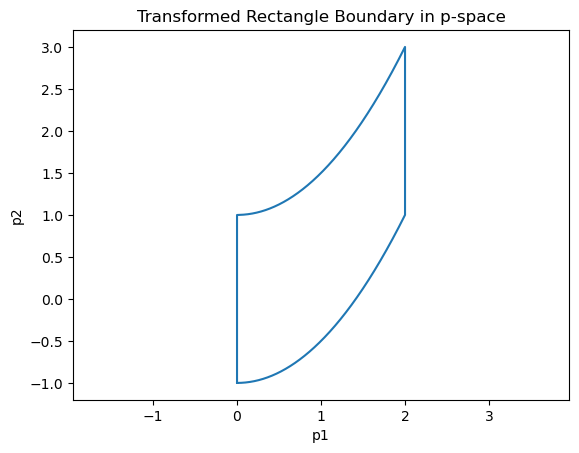

Approximate centroid [ 1.39207758 -1.48239929]
7.018390479604405


In [7]:
boundary_p = phi_inverse_boundary(sample_boundary_rectangle(0.0, 2.0, -1.0, 1.0, points_per_edge=2000), f, g)

plt.figure()
plt.plot(boundary_p[:,0], boundary_p[:,1])
plt.axis('equal')
plt.xlabel('p1')
plt.ylabel('p2')
plt.title('Transformed Rectangle Boundary in p-space')
plt.show()

def integrand_p1(x, y):
    return (1 / (f * f * g)) * Phi(np.array([x, y]), f, g)[0] * f_star_derivative(w1 - cost_function(Phi(np.array([x, y]), f, g)[0], Phi(np.array([x, y]), f, g)[1], z1[0], z1[1], f, g, cp, Pi0), gamma, kappa)
def integrand_p2(x, y):
    return (1 / (f * f * g)) * Phi(np.array([x, y]), f, g)[1] * f_star_derivative(w1 - cost_function(Phi(np.array([x, y]), f, g)[0], Phi(np.array([x, y]), f, g)[1], z1[0], z1[1], f, g, cp, Pi0), gamma, kappa)
def integrand_parea(x, y):
    return (1 / (f * f * g)) * f_star_derivative(w1 - cost_function(Phi(np.array([x, y]), f, g)[0], Phi(np.array([x, y]), f, g)[1], z1[0], z1[1], f, g, cp, Pi0), gamma, kappa)

# 3) Compute area integral:
z1 = np.array([1, 1])
w1 = 0
result_p1 = integrate_polygon(boundary_pts, integrand_p1) / integrate_polygon(boundary_pts, integrand_parea)
result_p2 = integrate_polygon(boundary_pts, integrand_p2) / integrate_polygon(boundary_pts, integrand_parea)
print("Approximate centroid", np.array([result_p1, result_p2]))

print(integrate_polygon(boundary_pts, integrand_parea))

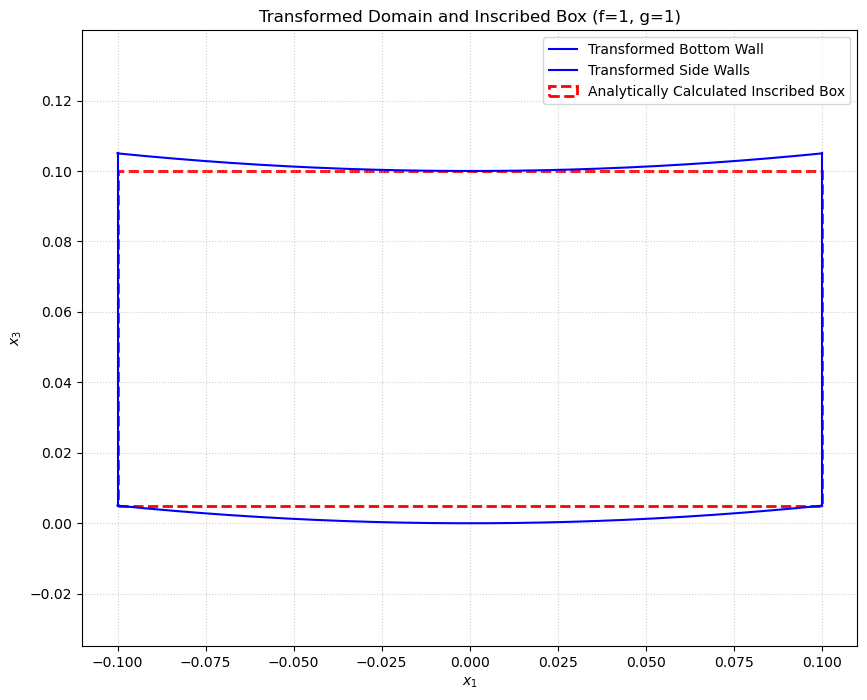

Original Box [p1_min, p3_min, p1_max, p3_max]: [-0.1, 0, 0.1, 0.1]
Inscribed Box [x1_min, x3_min, x1_max, x3_max]: [-0.1, 0.005000000000000001, 0.1, 0.1]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Define the Transformation and Calculation Functions ---

def expmap_inverse_vec(points, y, f, g):
    """
    Transforms points using the given mapping function.
    """
    p1, p3 = points[:, 0], points[:, 1]
    y1, y3 = y
    x1 = (f**2 / y3) * (p1 - y1)
    x3 = (g / y3**2) * p3 + (f**2 / (2 * y3**2)) * (p1 - y1)**2
    return np.stack((x1, x3), axis=1)

def find_inscribed_box_analytical(original_box, f, g, y=(0, 1)):
    """
    Calculates the inscribed box using the derived analytical formulas.
    """
    p1_min, p3_min, p1_max, p3_max = original_box
    y1, y3 = y

    # Horizontal boundaries
    x1_min_new = (f**2 / y3) * (p1_min - y1)
    x1_max_new = (f**2 / y3) * (p1_max - y1)

    # Vertical boundaries
    # Bottom is max of the lower parabola, which is at the wider x1 endpoint
    lower_parabola_at_min = (g / y3**2) * p3_min + (f**2 / (2 * y3**2)) * ((x1_min_new * y3 / f**2)**2)
    lower_parabola_at_max = (g / y3**2) * p3_min + (f**2 / (2 * y3**2)) * ((x1_max_new * y3 / f**2)**2)
    x3_min_inscribed = max(lower_parabola_at_min, lower_parabola_at_max)

    # Top is min of the upper parabola. Since x1=0 is in the domain, this is at the vertex.
    x3_max_inscribed = (g / y3**2) * p3_max

    return [x1_min_new, x3_min_inscribed, x1_max_new, x3_max_inscribed]

# --- 2. Set up Parameters and Data ---

# Define transformation parameters
f_param = 1
g_param = 1
y_map = (0, 1)

# Define the original box: [-1, 1] x [0, 1]
original_box_dims = [-0.1, 0, 0.1, 0.1]
p1_min, p3_min, p1_max, p3_max = original_box_dims

# Generate points for the boundaries of the original box
p1_vals = np.linspace(p1_min, p1_max, 200)
p3_vals = np.linspace(p3_min, p3_max, 200)

# Create the four walls of the box
bottom_wall = np.array([p1_vals, np.full_like(p1_vals, p3_min)]).T
top_wall = np.array([p1_vals, np.full_like(p1_vals, p3_max)]).T
left_wall = np.array([np.full_like(p3_vals, p1_min), p3_vals]).T
right_wall = np.array([np.full_like(p3_vals, p1_max), p3_vals]).T

# --- 3. Transform the Box and Calculate the Inscribed Box ---

# Transform each wall
trans_bottom = expmap_inverse_vec(bottom_wall, y_map, f_param, g_param)
trans_top = expmap_inverse_vec(top_wall, y_map, f_param, g_param)
trans_left = expmap_inverse_vec(left_wall, y_map, f_param, g_param)
trans_right = expmap_inverse_vec(right_wall, y_map, f_param, g_param)

# Calculate the inscribed box dimensions
inscribed_box_dims = find_inscribed_box_analytical(original_box_dims, f_param, g_param, y_map)
ix_min, iy_min, ix_max, iy_max = inscribed_box_dims
i_width = ix_max - ix_min
i_height = iy_max - iy_min

# --- 4. Plot the Results ---

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the transformed boundaries
ax.plot(trans_bottom[:, 0], trans_bottom[:, 1], 'b-', label='Transformed Bottom Wall')
ax.plot(trans_top[:, 0], trans_top[:, 1], 'b-')
ax.plot(trans_left[:, 0], trans_left[:, 1], 'b-', label='Transformed Side Walls')
ax.plot(trans_right[:, 0], trans_right[:, 1], 'b-')

# Create and plot the inscribed box rectangle
inscribed_rect = patches.Rectangle(
    (ix_min, iy_min), i_width, i_height,
    linewidth=2, edgecolor='r', facecolor='none', linestyle='--',
    label='Analytically Calculated Inscribed Box'
)
ax.add_patch(inscribed_rect)

# Formatting
ax.set_title(f'Transformed Domain and Inscribed Box (f={f_param}, g={g_param})')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_3$')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.axis('equal')
plt.show()

# Print the calculated dimensions for verification
print("Original Box [p1_min, p3_min, p1_max, p3_max]:", original_box_dims)
print("Inscribed Box [x1_min, x3_min, x1_max, x3_max]:", inscribed_box_dims)